In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve2d
from skimage.io import imread
import lib

In [2]:
rootfolder = '.'

Define the function to compute the kernel given the weights and the degree of the polynomial

In [3]:
# import from lib

Load the image and add the noise

In [4]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255

sigma_noise = 20/255
noisy_img = img + np.random.normal(size=img.shape) * sigma_noise

psnr_noisy = lib.get_psnr(img, noisy_img)

Text(0.5, 1.0, 'Noisy image, PSNR = 22.10')

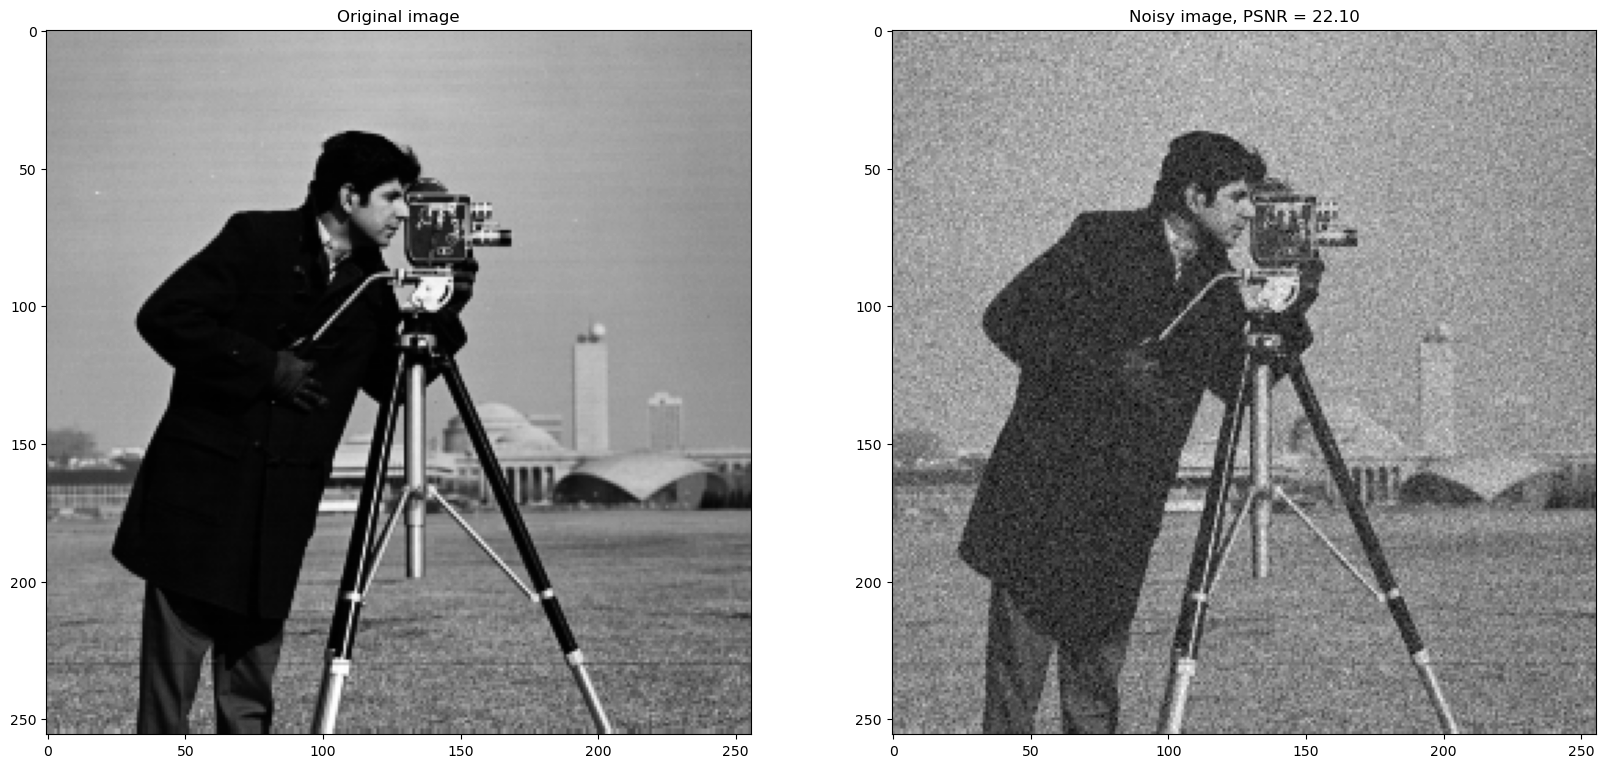

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

LPA-ICI 2D
----------
Set the LPA-ICI parameters

In [6]:
# maximum degree of polynomial used for fitting
N = 1

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# Set all the scale values
hmax = 21
all_h = np.arange(1, hmax+1)

Generate the LPA kernels for all the scale. Use centered weights.


In [7]:
all_g = []
for i, h in enumerate(all_h):
    # Define the weights for the scale h (symmetric)
    M = 2 * h - 1
    HFS = int((M - 1) / 2)

    w = np.zeros((M, M))

    # Specially treat the case of h = 1 and h = 2, otherwise there are no weights set to 1
    if h == 1:
        w[0, 0] = 1
    elif h == 2:
        w[1, 1] = 1
    else:
        w[int(HFS / 2):-int(HFS / 2), int(HFS / 2):-int(HFS / 2)] = 1

    # Compute and store the kernel g
    g = lib.compute_2D_LPA_kernel(w, N)
    all_g.append(g)

/Users/lorenzobenzoni/Documents/university/labs/MMIM/lib.py:432: RuntimeWarning: divide by zero encountered in divide
  winv = 1/w


Initialize all the variables for the ICI rule

In [8]:
# initialize the estimate for each scale
yhat = np.zeros((img.shape))

# initialize the vector containing the best scale for each sample
best_scale = np.zeros(shape=yhat.shape)

# initialize the lower and upper bound matrices
lower_bounds = - np.inf * np.ones(shape=yhat.shape)
upper_bounds = np.inf * np.ones(shape=yhat.shape) 

Loop over all the scales

In [9]:
for i, h in enumerate(all_h):
    g = all_g[i]

    # compute the estimate for the scale h
    yhat_h = convolve2d(noisy_img, g, 'same')
    sigma_h = sigma_noise * np.linalg.norm(g)

    # compute the lower and upper bound of the confidence interval for the scale h
    lb = yhat_h - Gamma * sigma_h
    ub = yhat_h + Gamma * sigma_h

    # update the lower and upper bounds
    lower_bounds = np.where(lb < lower_bounds, lower_bounds, lb)
    upper_bounds = np.where(ub > upper_bounds, upper_bounds, ub)

    # identify for which samples h is the best scale according to the
    # ICI rule and update the best_scale vector accordingly
    # update best_scale
    best_scale = np.where(lower_bounds < upper_bounds, h, best_scale)


    # update the estimate
    # update yhat
    yhat = np.where(lower_bounds < upper_bounds, yhat_h, yhat)

Compute the PSNR

In [10]:
psnr = lib.get_psnr(img, yhat)

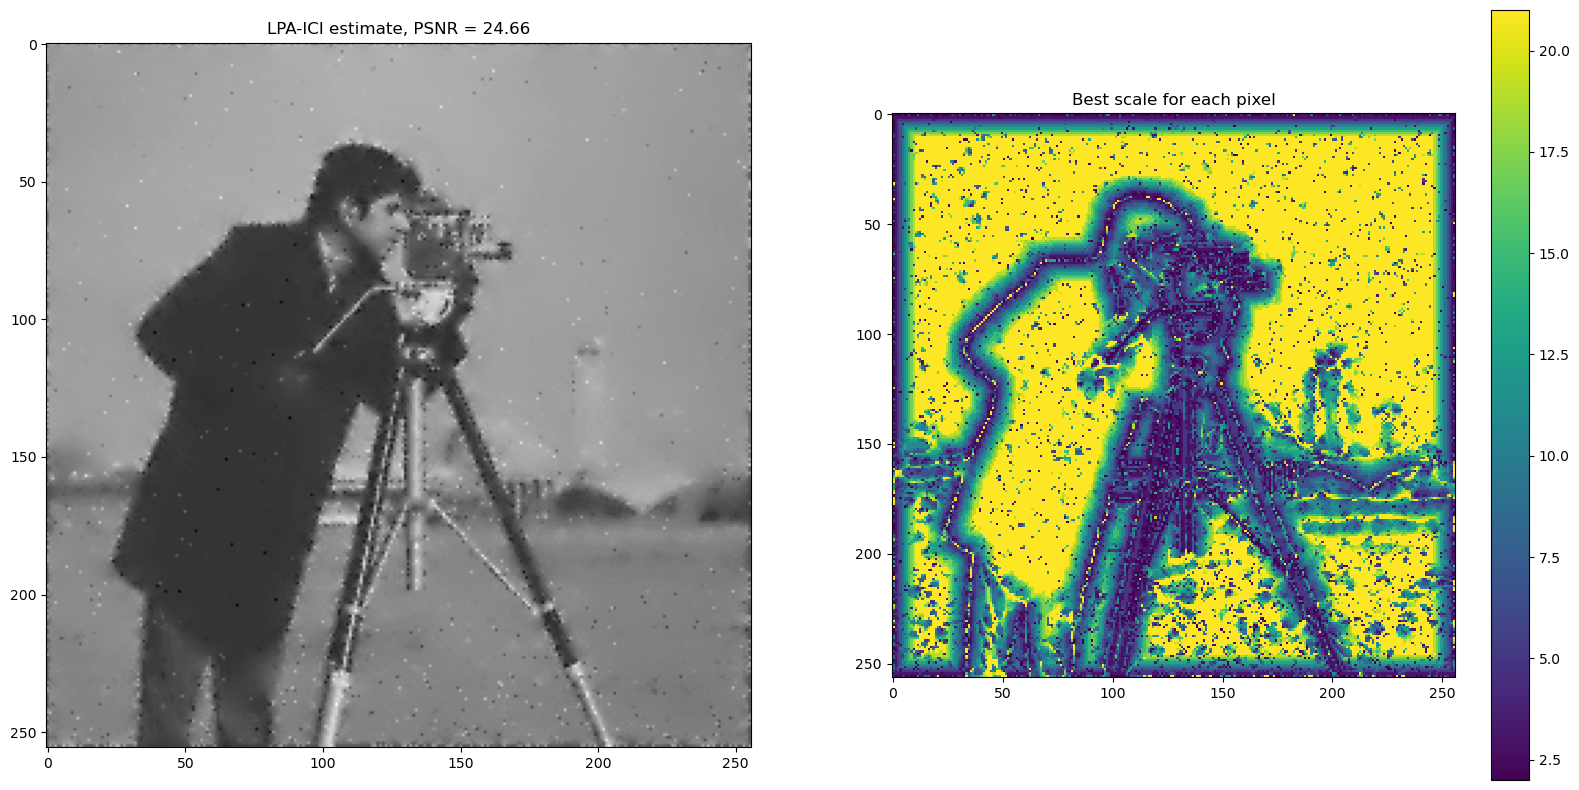

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(yhat, cmap='gray')
ax[0].set_title(f'LPA-ICI estimate, PSNR = {psnr:.2f}')

ax[1].imshow(best_scale)
ax[1].set_title('Best scale for each pixel')
fig.colorbar(ax[1].pcolormesh(best_scale), ax=ax[1])

Anisotropic LPA-ICI
------------------------
Set the parameters


In [19]:
# maximum degree of polynomial used for fitting
N = 3

# parameter for the confidence intervals in the ICI rule
Gamma = 2

# Set all the scale values
hmax = 21
all_h = np.arange(1, hmax+1)

# set all the direction values
all_theta = np.arange(4)

Generate the LPA kernels for all the scales and all the directions

In [20]:
all_g = []

for theta in all_theta:

    all_g_theta = []
    for i, h in enumerate(all_h):
        # define the weights for the scale h and the direction theta
        w = np.zeros((2*h-1, 2*h-1))
        HFS = int((2 * h - 2)/2)
        if theta == 0:
        # only the upper left corner is weighted
            w[:HFS+1, :HFS+1] = 1
        elif theta == 1:
        # only the upper right corner is weighted
            w[:HFS+1, HFS:] = 1

        elif theta == 2:
        # only the lower right corner is weighted
            w[HFS:, HFS:] = 1
        
        elif theta == 3:
        # only the lower left corner is weighted
            w[HFS:, :HFS+1] = 1

        # compute and store the kernel g
        g = lib.compute_2D_LPA_kernel(w, N)

        all_g_theta.append(g)
    
    all_g.append(all_g_theta)


/Users/lorenzobenzoni/Documents/university/labs/MMIM/lib.py:432: RuntimeWarning: divide by zero encountered in divide
  winv = 1/w


Initialize all the variables 

In [21]:
# initialize the estimate for each scale
y_hat = np.zeros(img.shape)

# initialize the matrix of the aggregation weights
weights = np.zeros(img.shape)


Use the LPA-ICI to compute find the best scale for each direction and compute the finale estimates

In [22]:
# Loop over all the directions
for theta in all_theta:
    # Initialize the estimate for the direction theta
    y_hat_theta = np.zeros(img.shape) 
    
    # Initialize the matrix of all the variances for the direction theta
    var_theta = np.zeros(img.shape) 

    # Initialize the lower and upper bounds matrices
    lower_bounds = - np.inf * np.ones(img.shape)
    upper_bounds = np.inf * np.ones(img.shape)

    # Loop over all scales
    all_g_theta = all_g[theta]
    for i, h in enumerate(all_h):
        g = all_g_theta[i]

        # Compute the estimate for the scale h
        y_hat_h = convolve2d(noisy_img, g, mode='same')
        sigma_h = sigma_noise * np.linalg.norm(g)

        # Compute the lower and upper bound of the confidence interval for the scale h
        lb = y_hat_h - Gamma * sigma_h
        ub = y_hat_h + Gamma * sigma_h

        # Update the lower and upper bounds
        lower_bounds = np.maximum(lower_bounds, lb)
        upper_bounds = np.minimum(upper_bounds, ub)

        # Update the estimate
        # Update y_hat_theta
        idx = lower_bounds < upper_bounds
        y_hat_theta[idx] = y_hat_h[idx]

        # Update the matrix with the variances
        # Update var_theta
        var_theta[idx] = sigma_h ** 2
      
    # Update the estimates and the weights
    y_hat += y_hat_theta / var_theta
    weights += 1 / var_theta

# Compute the final estimates
y_hat = y_hat / weights

Compute the PSNR

In [23]:
psnr = lib.get_psnr(img, y_hat)

Text(0.5, 1.0, 'LPA-ICI estimate, PSNR = 26.50')

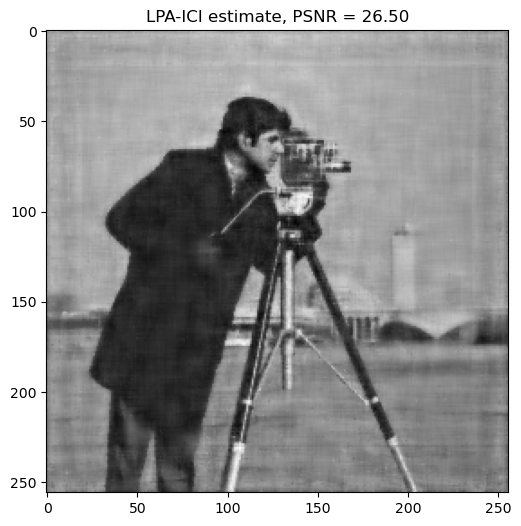

In [24]:
plt.figure(figsize=(6,6))
plt.imshow(y_hat, cmap='gray')
plt.title(f'LPA-ICI estimate, PSNR = {psnr:.2f}')

Model selection for the anisotropic LPA-ICI, in order to fine the best Ns

I use a linesearch approach

Indeed, the best poly fit is N = 1

In [27]:
for i in range(1, 8):
    N = i
    # parameter for the confidence intervals in the ICI rule
    Gamma = 2

    # Set all the scale values
    hmax = 21
    all_h = np.arange(1, hmax+1)

    # set all the direction values
    all_theta = np.arange(4)

    # initialize the estimate for each scale
    y_hat = np.zeros(img.shape)

    # initialize the matrix of the aggregation weights
    weights = np.zeros(img.shape)

    all_g = []

    for theta in all_theta:

        all_g_theta = []
        for i, h in enumerate(all_h):
            # define the weights for the scale h and the direction theta
            w = np.zeros((2*h-1, 2*h-1))
            HFS = int((2 * h - 2)/2)
            if theta == 0:
            # only the upper left corner is weighted
                w[:HFS+1, :HFS+1] = 1
            elif theta == 1:
            # only the upper right corner is weighted
                w[:HFS+1, HFS:] = 1

            elif theta == 2:
            # only the lower right corner is weighted
                w[HFS:, HFS:] = 1
            
            elif theta == 3:
            # only the lower left corner is weighted
                w[HFS:, :HFS+1] = 1

            # compute and store the kernel g
            g = lib.compute_2D_LPA_kernel(w, N)

            all_g_theta.append(g)
        
        all_g.append(all_g_theta)

    # Loop over all the directions
    for theta in all_theta:
        # Initialize the estimate for the direction theta
        y_hat_theta = np.zeros(img.shape) 
        
        # Initialize the matrix of all the variances for the direction theta
        var_theta = np.zeros(img.shape) 

        # Initialize the lower and upper bounds matrices
        lower_bounds = - np.inf * np.ones(img.shape)
        upper_bounds = np.inf * np.ones(img.shape)

        # Loop over all scales
        all_g_theta = all_g[theta]
        for i, h in enumerate(all_h):
            g = all_g_theta[i]

            # Compute the estimate for the scale h
            y_hat_h = convolve2d(noisy_img, g, mode='same')
            sigma_h = sigma_noise * np.linalg.norm(g)

            # Compute the lower and upper bound of the confidence interval for the scale h
            lb = y_hat_h - Gamma * sigma_h
            ub = y_hat_h + Gamma * sigma_h

            # Update the lower and upper bounds
            lower_bounds = np.maximum(lower_bounds, lb)
            upper_bounds = np.minimum(upper_bounds, ub)

            # Update the estimate
            # Update y_hat_theta
            idx = lower_bounds < upper_bounds
            y_hat_theta[idx] = y_hat_h[idx]

            # Update the matrix with the variances
            # Update var_theta
            var_theta[idx] = sigma_h ** 2
        
        # Update the estimates and the weights
        y_hat += y_hat_theta / var_theta
        weights += 1 / var_theta

    # Compute the final estimates
    y_hat = y_hat / weights

    psnr = lib.get_psnr(img, y_hat)

    print(f'N = {N}, PSNR = {psnr:.2f}')


N = 1, PSNR = 27.48
N = 2, PSNR = 27.02
N = 3, PSNR = 26.50
N = 4, PSNR = 25.99
N = 5, PSNR = 25.55
N = 6, PSNR = 24.90
N = 7, PSNR = 24.32
